In [3]:
# %% 데이터 로드
import glob, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# seaborn 스타일을 먼저 적용 (이게 폰트를 덮어쓸 수 있어서 순서 중요!)
sns.set_style('whitegrid')

# 그 다음 한글 폰트 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 출력 옵션
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:,.2f}'.format)
 
from pathlib import Path
 
current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent
 
# ── 추정매출 로드 (기존 코드 재사용) ──
DATA_DIR = str(project_root / 'data' / 'extracted' / '서울시_상권분석서비스(추정매출+영역)') + '/'
pattern = DATA_DIR + '*추정매출*.csv'
sales_files = sorted(glob.glob(pattern))
print(f'추정매출 파일: {len(sales_files)}개')
 
sales = pd.concat(
    [pd.read_csv(f, encoding='cp949', low_memory=False) for f in sales_files],
    ignore_index=True
)
print(f'  → 통합: {sales.shape[0]:,}행 × {sales.shape[1]}컬럼')
 
# ── 영역 로드 ──
area_path = glob.glob(DATA_DIR + '*영역*상권*.csv')[0]
area = pd.read_csv(area_path, encoding='cp949')
print(f'영역: {area.shape[0]:,}개 상권')
 
# ── 길단위인구(유동인구) 로드 ──
floating_path = project_root / 'data' / 'extracted' / '서울시 상권분석서비스(길단위인구-상권)' / '서울시 상권분석서비스(길단위인구-상권).csv'
floating = pd.read_csv(floating_path, encoding='cp949')
print(f'유동인구: {floating.shape[0]:,}행 × {floating.shape[1]}컬럼')
 
# ── 직장인구 로드 ──
work_path = project_root / 'data' / '06_직장인구' / '서울시 상권분석서비스(직장인구-상권).csv'
df_직장 = pd.read_csv(work_path, encoding='cp949')
print(f'직장인구: {df_직장.shape[0]:,}행 × {df_직장.shape[1]}컬럼')
 
# ── 상주인구 로드 ──
resident_path = project_root / 'data' / '07_상주인구' / '서울시 상권분석서비스(상주인구-상권).csv'
df_상주 = pd.read_csv(resident_path, encoding='cp949')
print(f'상주인구: {df_상주.shape[0]:,}행 × {df_상주.shape[1]}컬럼')
 
print('\n✅ 전체 데이터 로드 완료')

추정매출 파일: 6개
  → 통합: 519,931행 × 55컬럼
영역: 1,650개 상권
유동인구: 46,184행 × 27컬럼
직장인구: 45,840행 × 26컬럼
상주인구: 40,812행 × 29컬럼

✅ 전체 데이터 로드 완료


In [4]:
# ── 컬럼 정의 (분석 3 독립 실행용) ──
시간_매출 = ['시간대_00~06_매출_금액','시간대_06~11_매출_금액','시간대_11~14_매출_금액',
           '시간대_14~17_매출_금액','시간대_17~21_매출_금액','시간대_21~24_매출_금액']
시간라벨 = ['00-06','06-11','11-14','14-17','17-21','21-24']
순서 = ['골목상권','발달상권','관광특구','전통시장']

In [5]:
# ── 상권 단위 시간대별 매출 집계 ──
sales_time2 = sales.groupby(
    ['기준_년분기_코드', '상권_코드', '상권_구분_코드_명']
)[시간_매출 + ['당월_매출_금액', '주중_매출_금액', '주말_매출_금액']].sum().reset_index()
 
sales_time2['저녁비중'] = sales_time2['시간대_17~21_매출_금액'] / sales_time2['당월_매출_금액'] * 100
sales_time2['주말비중'] = sales_time2['주말_매출_금액'] / sales_time2['당월_매출_금액'] * 100
sales_time2['야간비중'] = sales_time2['시간대_21~24_매출_금액'] / sales_time2['당월_매출_금액'] * 100
sales_time2['점심비중'] = sales_time2['시간대_11~14_매출_금액'] / sales_time2['당월_매출_금액'] * 100

In [6]:
# ── 상주인구 + 직장인구 합치기 ──
merged_res = sales_time2.merge(
    df_상주[['기준_년분기_코드', '상권_코드', '총_상주인구_수']],
    on=['기준_년분기_코드', '상권_코드'], how='inner'
)
merged_res = merged_res.merge(
    df_직장[['기준_년분기_코드', '상권_코드', '총_직장_인구_수']],
    on=['기준_년분기_코드', '상권_코드'], how='inner'
)
merged_res = merged_res.merge(area[['상권_코드', '영역_면적']], on='상권_코드', how='left')

In [9]:
# 상주/직장 비율
merged_res['상주_직장_비율'] = merged_res['총_상주인구_수'] / merged_res['총_직장_인구_수'].replace(0, np.nan)
 
merged_res.info()

<class 'pandas.DataFrame'>
RangeIndex: 37137 entries, 0 to 37136
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   기준_년분기_코드        37137 non-null  int64  
 1   상권_코드            37137 non-null  int64  
 2   상권_구분_코드_명       37137 non-null  str    
 3   시간대_00~06_매출_금액  37137 non-null  int64  
 4   시간대_06~11_매출_금액  37137 non-null  int64  
 5   시간대_11~14_매출_금액  37137 non-null  int64  
 6   시간대_14~17_매출_금액  37137 non-null  int64  
 7   시간대_17~21_매출_금액  37137 non-null  int64  
 8   시간대_21~24_매출_금액  37137 non-null  int64  
 9   당월_매출_금액         37137 non-null  int64  
 10  주중_매출_금액         37137 non-null  int64  
 11  주말_매출_금액         37137 non-null  int64  
 12  저녁비중             37137 non-null  float64
 13  주말비중             37137 non-null  float64
 14  야간비중             37137 non-null  float64
 15  점심비중             37137 non-null  float64
 16  총_상주인구_수         37137 non-null  int64  
 17  총_직장_인구_수        37137 

In [10]:
# %% 상관계수 분석
상권 = ['골목상권', '발달상권', '관광특구', '전통시장']
 
print('📊 상권구분별 상주인구 vs 저녁/주말 비중')
print('-' * 75)
print(f'{"유형":<10} {"평균상주인구":>10} {"저녁비중":>8} {"주말비중":>8} {"상관(저녁)":>10} {"상관(주말)":>10}')
print('-' * 75)
for 구분 in 순서:
    sub = merged_res[merged_res['상권_구분_코드_명'] == 구분]
    corr_저녁 = sub[['총_상주인구_수', '저녁비중']].corr().iloc[0, 1]
    corr_주말 = sub[['총_상주인구_수', '주말비중']].corr().iloc[0, 1]
    print(f'{구분:<10} {sub["총_상주인구_수"].mean():>9,.0f}명 {sub["저녁비중"].mean():>7.1f}%'
          f' {sub["주말비중"].mean():>7.1f}% {corr_저녁:>9.3f} {corr_주말:>9.3f}')

📊 상권구분별 상주인구 vs 저녁/주말 비중
---------------------------------------------------------------------------
유형             평균상주인구     저녁비중     주말비중     상관(저녁)     상관(주말)
---------------------------------------------------------------------------
골목상권           2,878명    32.1%    24.5%    -0.033     0.023
발달상권           2,366명    27.9%    21.6%     0.182     0.159
관광특구           3,242명    28.2%    29.1%     0.463     0.542
전통시장             722명    30.4%    26.0%     0.079    -0.012


In [11]:
# %% 상주/직장 비율 5분위별 분석
merged_res['비율_구간'] = pd.qcut(
    merged_res['상주_직장_비율'].dropna(), q=5, duplicates='drop',
    labels=['직장 우위', '직장 약간 우위', '균형', '상주 약간 우위', '상주 우위']
)
 
비율별 = merged_res.groupby('비율_구간').agg(
    평균비율=('상주_직장_비율', 'mean'),
    점심비중=('점심비중', 'mean'),
    저녁비중=('저녁비중', 'mean'),
    주말비중=('주말비중', 'mean'),
    n=('상권_코드', 'count')
).reset_index()
 
print('📊 상주/직장 비율별 시간대 매출 비중')
print('-' * 65)
print(f'{"구간":<14} {"상주/직장":>10} {"점심비중":>8} {"저녁비중":>8} {"주말비중":>8} {"n":>6}')
print('-' * 65)
for _, row in 비율별.iterrows():
    print(f'{row["비율_구간"]:<14} {row["평균비율"]:>9.1f}배 {row["점심비중"]:>7.1f}%'
          f' {row["저녁비중"]:>7.1f}% {row["주말비중"]:>7.1f}% {row["n"]:>5,}')

📊 상주/직장 비율별 시간대 매출 비중
-----------------------------------------------------------------
구간                  상주/직장     점심비중     저녁비중     주말비중      n
-----------------------------------------------------------------
직장 우위                0.2배    28.9%    27.7%    21.9% 7,428
직장 약간 우위             1.2배    26.6%    29.8%    23.5% 7,430
균형                   3.4배    24.5%    31.4%    24.7% 7,427
상주 약간 우위             7.4배    23.0%    32.8%    25.6% 7,424
상주 우위               28.0배    20.7%    33.9%    26.0% 7,428


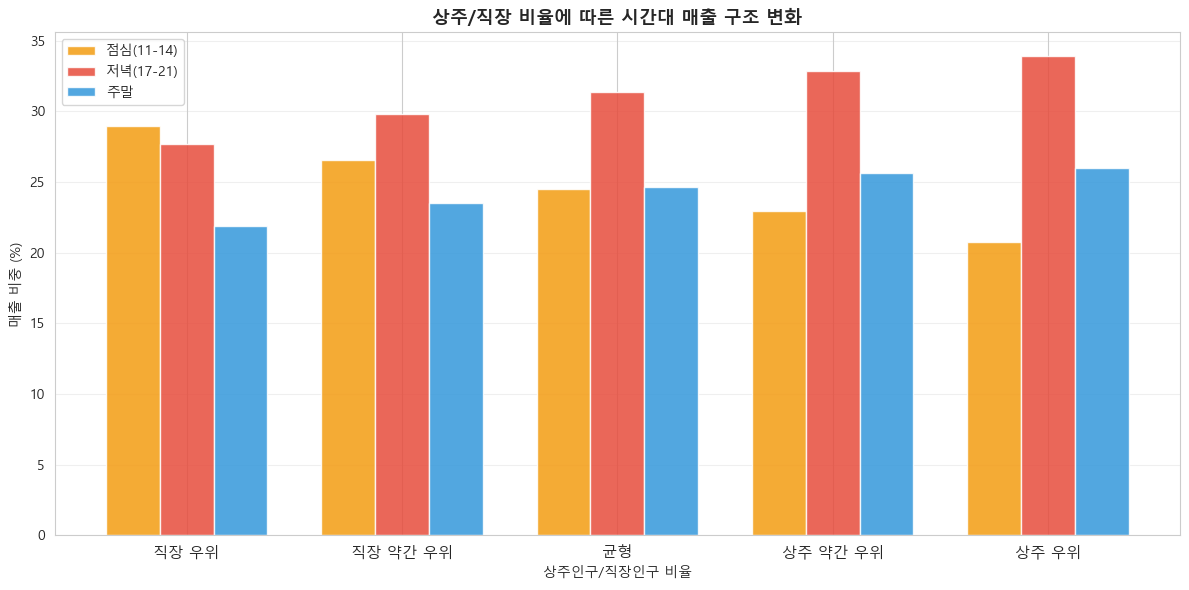

In [12]:
# %% 상주/직장 비율별 시각화
fig, ax = plt.subplots(figsize=(12, 6))
 
x = np.arange(len(비율별))
w = 0.25
 
ax.bar(x - w, 비율별['점심비중'], w, color='#F39C12', alpha=0.85, label='점심(11-14)')
ax.bar(x, 비율별['저녁비중'], w, color='#E74C3C', alpha=0.85, label='저녁(17-21)')
ax.bar(x + w, 비율별['주말비중'], w, color='#3498DB', alpha=0.85, label='주말')
 
ax.set_xticks(x)
ax.set_xticklabels(비율별['비율_구간'], fontsize=11)
ax.set_ylabel('매출 비중 (%)')
ax.set_xlabel('상주인구/직장인구 비율')
ax.set_title('상주/직장 비율에 따른 시간대 매출 구조 변화', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# %% 2×2 조합 분석
merged_res['직장_수준'] = pd.qcut(merged_res['총_직장_인구_수'], q=2, labels=['직장少', '직장多'])
merged_res['상주_수준'] = pd.qcut(merged_res['총_상주인구_수'], q=2, labels=['상주少', '상주多'])
merged_res['조합'] = merged_res['직장_수준'].astype(str) + ' × ' + merged_res['상주_수준'].astype(str)
 
조합순서 = ['직장少 × 상주少', '직장少 × 상주多', '직장多 × 상주少', '직장多 × 상주多']
시간라벨2 = ['00-06', '06-11', '11-14', '14-17', '17-21', '21-24']

In [14]:
# 조합별 시간대 비중 계산
조합_data = {}
for 조합 in 조합순서:
    sub = merged_res[merged_res['조합'] == 조합]
    vals = [(sub[col] / sub['당월_매출_금액'] * 100).mean() for col in 시간_매출]
    주말 = (sub['주말_매출_금액'] / sub['당월_매출_금액'] * 100).mean()
    조합_data[조합] = {'시간대': vals, '주말': 주말, 'n': len(sub)}
 

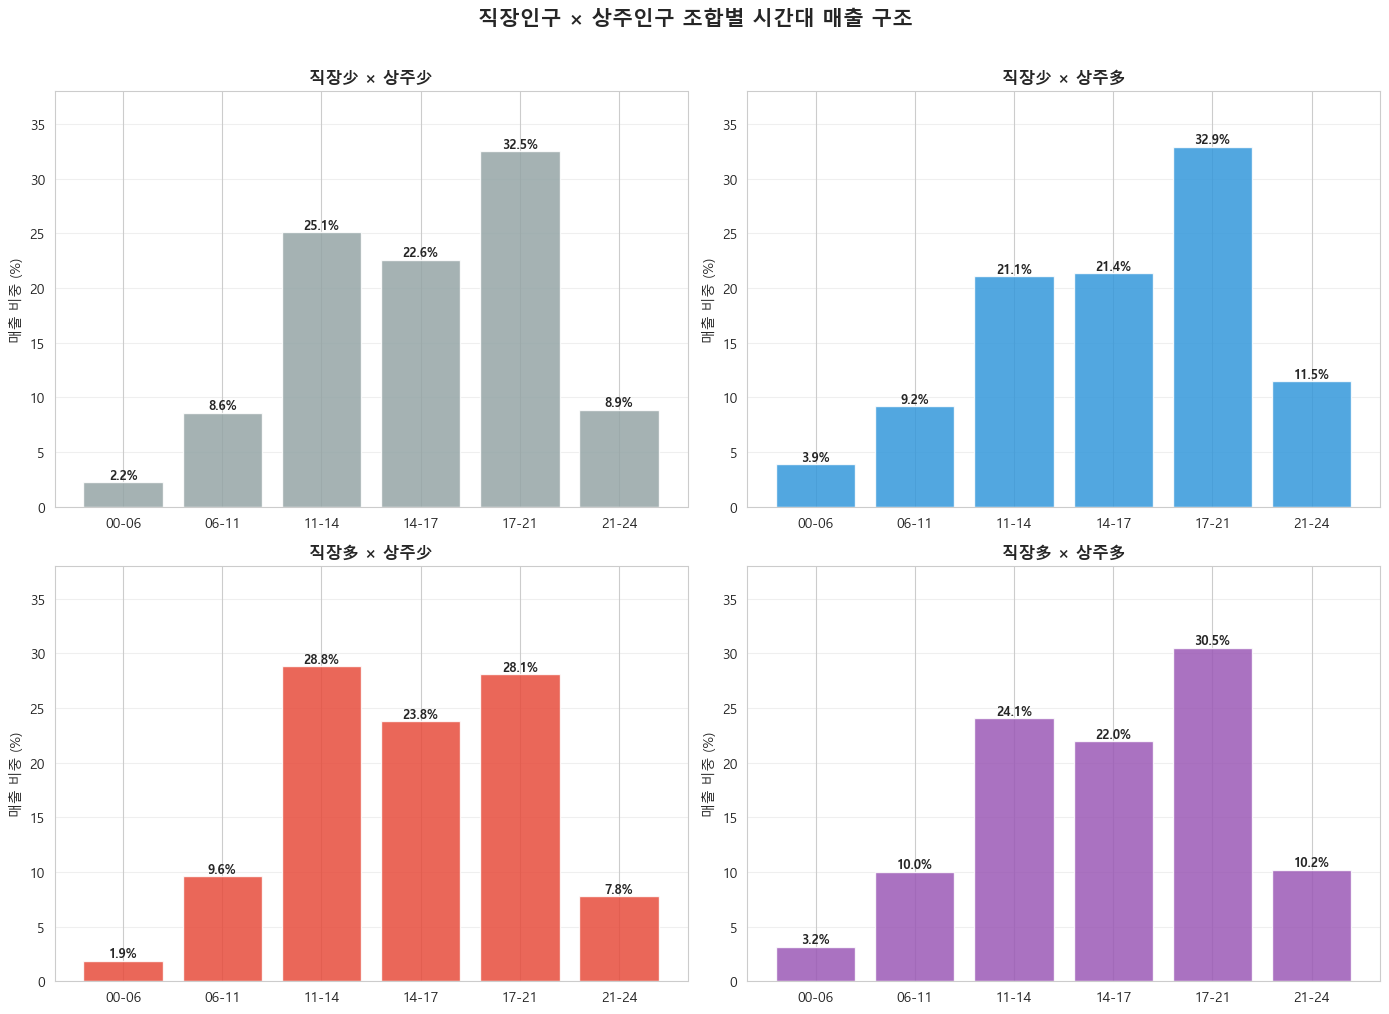

In [20]:
# 시각화: 2×2 히트맵 스타일
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
조합_색상 = {'직장少 × 상주少': '#95A5A6', '직장少 × 상주多': '#3498DB',
           '직장多 × 상주少': '#E74C3C', '직장多 × 상주多': '#9B59B6'}
 
for idx, 조합 in enumerate(조합순서):
    ax = axes[idx // 2][idx % 2]
    vals = 조합_data[조합]['시간대']
    bars = ax.bar(range(6), vals, color=조합_색상[조합], alpha=0.85, edgecolor='white')
    ax.set_xticks(range(6))
    ax.set_xticklabels(시간라벨2, fontsize=10)
    ax.set_ylabel('매출 비중 (%)')
    ax.set_title(f'{조합}', fontweight='bold', fontsize=12)
    ax.set_ylim(0, 38)
    ax.grid(axis='y', alpha=0.3)
 
    # 수치 표시
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
 
fig.suptitle('직장인구 × 상주인구 조합별 시간대 매출 구조', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [21]:
# %% 업종별 상주인구 효과
저녁_업종 = sales.copy()
저녁_업종['저녁비중'] = 저녁_업종['시간대_17~21_매출_금액'] / 저녁_업종['당월_매출_금액'].replace(0, np.nan) * 100
 
저녁_업종 = 저녁_업종.merge(
    df_상주[['기준_년분기_코드', '상권_코드', '총_상주인구_수']],
    on=['기준_년분기_코드', '상권_코드'], how='inner'
)
 
q80_res = merged_res['총_상주인구_수'].quantile(0.8)
q20_res = merged_res['총_상주인구_수'].quantile(0.2)
 
저녁_상위 = 저녁_업종[저녁_업종['총_상주인구_수'] >= q80_res].groupby('서비스_업종_코드_명')['저녁비중'].mean()
저녁_하위 = 저녁_업종[저녁_업종['총_상주인구_수'] <= q20_res].groupby('서비스_업종_코드_명')['저녁비중'].mean()
차이_저녁 = (저녁_상위 - 저녁_하위).dropna().sort_values(ascending=False)

In [22]:
저녁_상위

서비스_업종_코드_명
PC방       30.63
가구        23.58
가방        33.16
가전제품      25.54
가전제품수리    17.79
           ... 
한의원       20.88
핸드폰       33.62
호프-간이주점   29.23
화장품       29.23
화초        30.86
Name: 저녁비중, Length: 63, dtype: float64

In [23]:
저녁_하위

서비스_업종_코드_명
PC방       32.32
가구        22.35
가방        25.11
가전제품      17.61
가전제품수리    14.01
           ... 
한의원       20.06
핸드폰       31.57
호프-간이주점   28.67
화장품       28.39
화초        22.36
Name: 저녁비중, Length: 62, dtype: float64

In [24]:
차이_저녁

서비스_업종_코드_명
자전거 및 기타운송장비    28.61
애완동물            16.72
미곡판매            12.06
부동산중개업          11.54
세탁소              9.79
                ...  
피부관리실           -0.92
PC방             -1.69
자동차수리           -2.34
노래방             -3.91
자동차미용          -22.66
Name: 저녁비중, Length: 62, dtype: float64

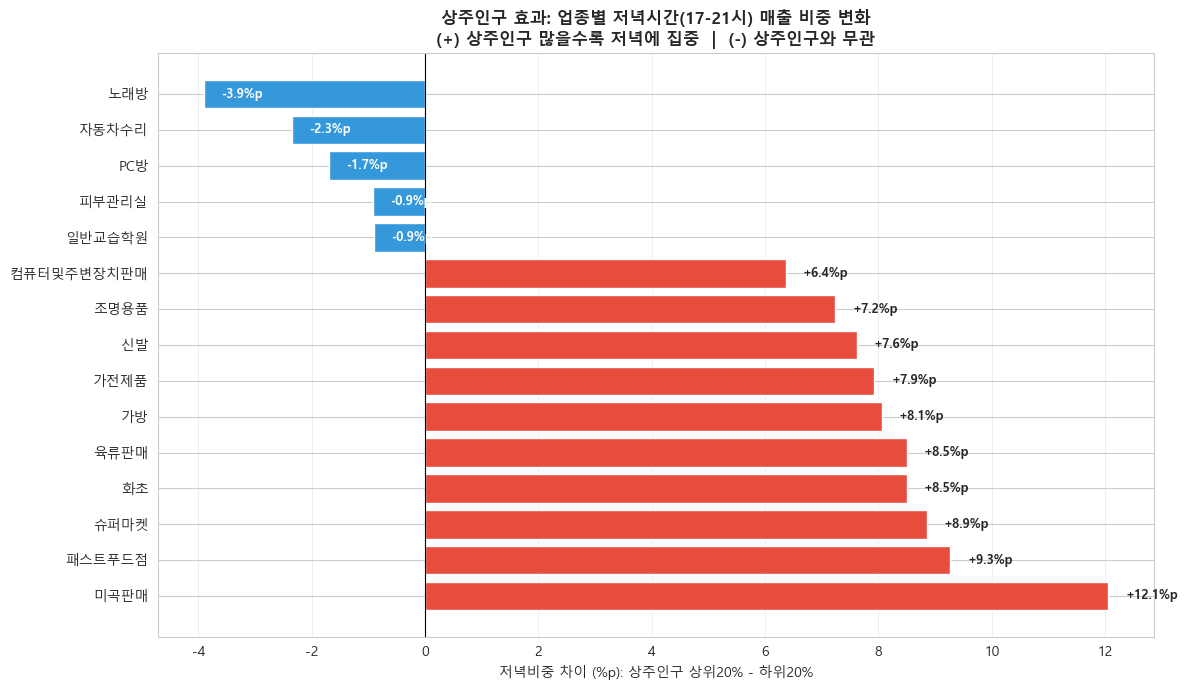

In [25]:
# 주요 업종만 필터 (너무 특수한 업종 제외)
주요업종 = sales.groupby('서비스_업종_코드_명')['당월_매출_금액'].sum()
주요업종 = 주요업종[주요업종 > 주요업종.quantile(0.2)].index
차이_저녁_필터 = 차이_저녁[차이_저녁.index.isin(주요업종)]
 
top10 = 차이_저녁_필터.head(10)
bot5 = 차이_저녁_필터.tail(5)
plot_data3 = pd.concat([top10, bot5])
 
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#E74C3C' if v > 0 else '#3498DB' for v in plot_data3.values]
bars = ax.barh(range(len(plot_data3)), plot_data3.values, color=colors, edgecolor='white')
ax.set_yticks(range(len(plot_data3)))
ax.set_yticklabels(plot_data3.index)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('저녁비중 차이 (%p): 상주인구 상위20% - 하위20%')
ax.set_title('상주인구 효과: 업종별 저녁시간(17-21시) 매출 비중 변화\n(+) 상주인구 많을수록 저녁에 집중  |  (-) 상주인구와 무관',
             fontweight='bold')
ax.grid(axis='x', alpha=0.3)
 
for i, (bar, val) in enumerate(zip(bars, plot_data3.values)):
    if val < 0:
        ax.text(val + 0.3, i, f'{val:+.1f}%p', va='center', ha='left',
                fontsize=9, fontweight='bold', color='white')
    else:
        ax.text(val + 0.3, i, f'{val:+.1f}%p', va='center', ha='left',
                fontsize=9, fontweight='bold')
 
plt.tight_layout()
plt.show()

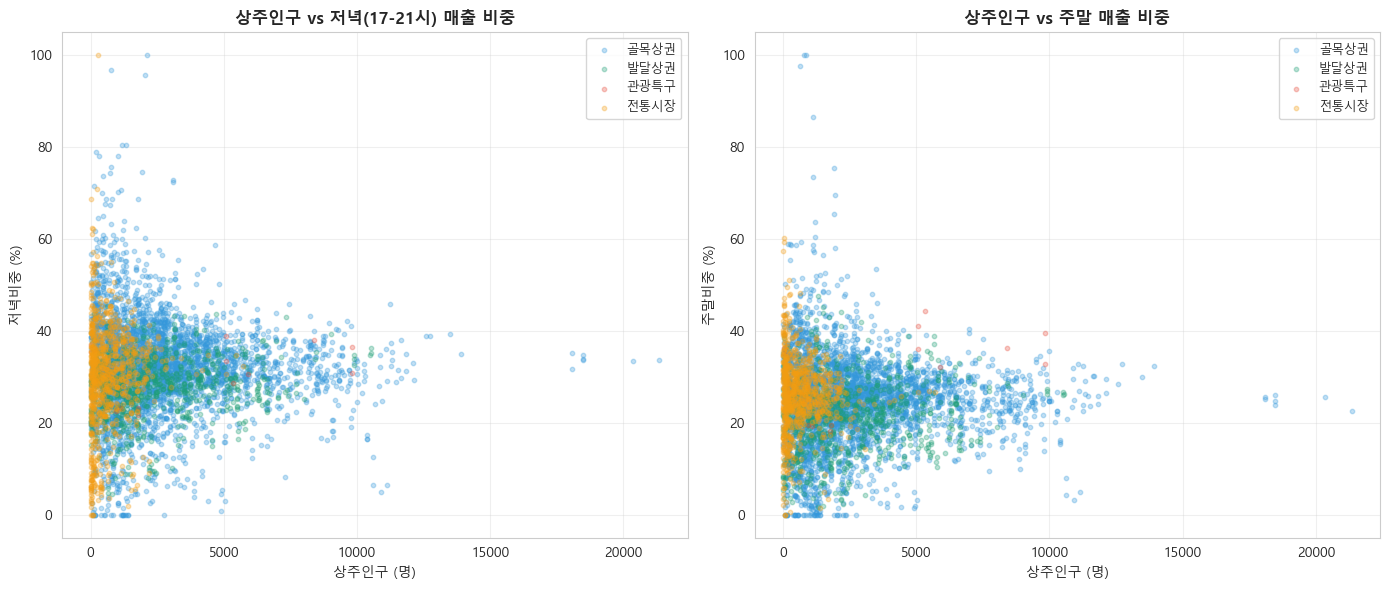

In [26]:
# %% 산점도: 상주인구 vs 저녁비중 / 주말비중
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# 저녁비중
ax1 = axes[0]
sample = merged_res.sample(n=5000, random_state=42)
색_map = {'골목상권':'#3498DB','발달상권':'#1D9E75','관광특구':'#E74C3C','전통시장':'#F39C12'}
for 구분 in 순서:
    sub = sample[sample['상권_구분_코드_명'] == 구분]
    ax1.scatter(sub['총_상주인구_수'], sub['저녁비중'], alpha=0.3, s=10, color=색_map[구분], label=구분)
ax1.set_xlabel('상주인구 (명)')
ax1.set_ylabel('저녁비중 (%)')
ax1.set_title('상주인구 vs 저녁(17-21시) 매출 비중', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)
 
# 주말비중
ax2 = axes[1]
for 구분 in 순서:
    sub = sample[sample['상권_구분_코드_명'] == 구분]
    ax2.scatter(sub['총_상주인구_수'], sub['주말비중'], alpha=0.3, s=10, color=색_map[구분], label=구분)
ax2.set_xlabel('상주인구 (명)')
ax2.set_ylabel('주말비중 (%)')
ax2.set_title('상주인구 vs 주말 매출 비중', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
 
plt.tight_layout()
plt.show()